In [105]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/faizanhaider01/glass/glass.csv


In [106]:
df = pd.read_csv("/kaggle/input/datasets/faizanhaider01/glass/glass.csv",usecols = ['Na','Si','Type'])

In [107]:
df.sample(4)

,Na,Si,Type
93,13.24,73.10,2
45,13.49,71.95,1
94,12.71,73.28,2
153,13.42,72.69,3


In [108]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer

In [109]:
X = df.iloc[:,0:2]
y = df.iloc[:,2]

In [110]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [111]:
X_train.head(2)

,Na,Si
79,12.82,72.86
161,13.64,72.65


In [112]:
clf = DecisionTreeClassifier()

In [113]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.4418604651162791

In [114]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=9,scoring='accuracy'))

np.float64(0.4066022544283414)

In [115]:
kbin_na = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_si = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [116]:

trf = ColumnTransformer([
    ('first',kbin_na,[0]),
    ('second',kbin_si,[1])
])

In [117]:

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [118]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=10),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10)}

In [119]:
trf.named_transformers_['first'].bin_edges_

array([array([10.73, 12.72, 12.86, 13.  , 13.15, 13.3 , 13.43, 13.69, 13.99,
              14.38, 15.79])                                                ],
      dtype=object)

In [120]:
trf.named_transformers_['second'].bin_edges_

array([array([69.81, 71.76, 72.08, 72.38, 72.64, 72.75, 72.86, 72.98, 73.09,
              73.27, 75.18])                                                ],
      dtype=object)

In [121]:
output = pd.DataFrame({
    'Na':X_train['Na'],
    'Na_trf':X_train_trf[:,0],
    'Si':X_train['Si'],
    'Si_trf':X_train_trf[:,1]
})

In [122]:
output['Na_labels'] = pd.cut(x=X_train['Na'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['Si_labels'] = pd.cut(x=X_train['Si'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [123]:
output.head(5)

,Na,Na_trf,Si,Si_trf,Na_labels,Si_labels
79,12.82,1.0,72.86,6.0,"(12.72, 12.86]","(72.75, 72.86]"
161,13.64,6.0,72.65,4.0,"(13.43, 13.69]","(72.64, 72.75]"
109,13.72,7.0,74.45,9.0,"(13.69, 13.99]","(73.27, 75.18]"
127,13.78,7.0,71.99,1.0,"(13.69, 13.99]","(71.76, 72.08]"
95,13.36,5.0,72.26,2.0,"(13.3, 13.43]","(72.08, 72.38]"


In [124]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [125]:
accuracy_score(y_test,y_pred2)

0.4883720930232558

In [126]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=9,scoring='accuracy'))

np.float64(0.429951690821256)

In [129]:
def discretize(bins,strategy):
    kbin_na = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_si = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_na,[0]),
        ('second',kbin_si,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=9,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Na'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Si'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Si")

    plt.show()

0.42954911433172305


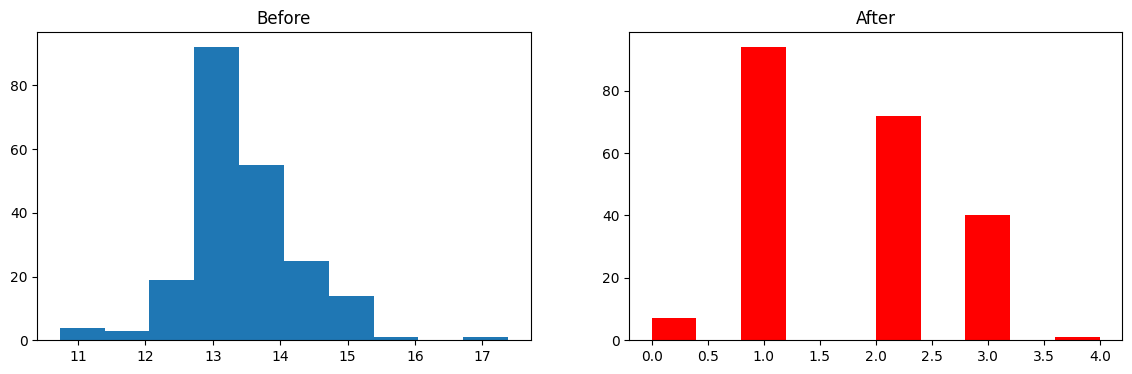

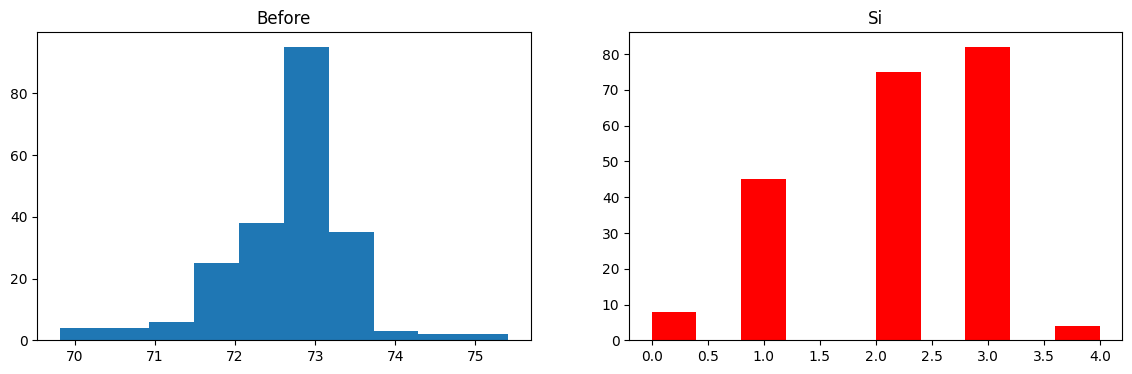

In [131]:
discretize(5,'kmeans')

0.4110305958132045


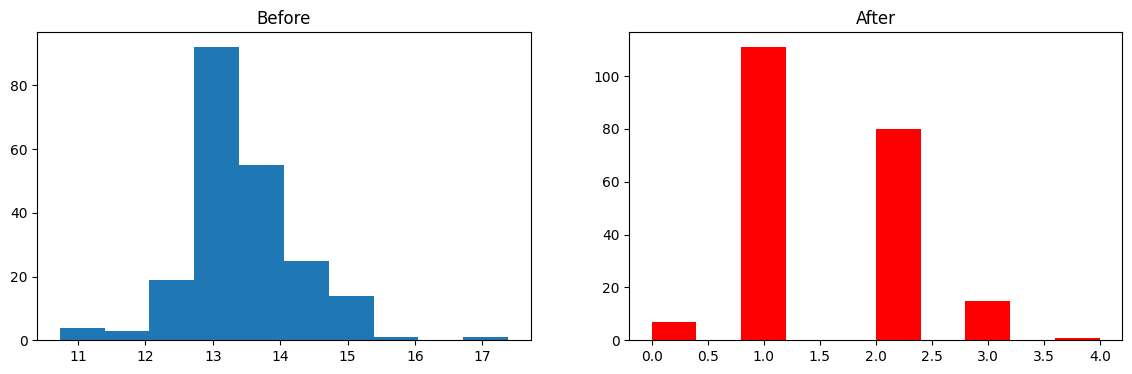

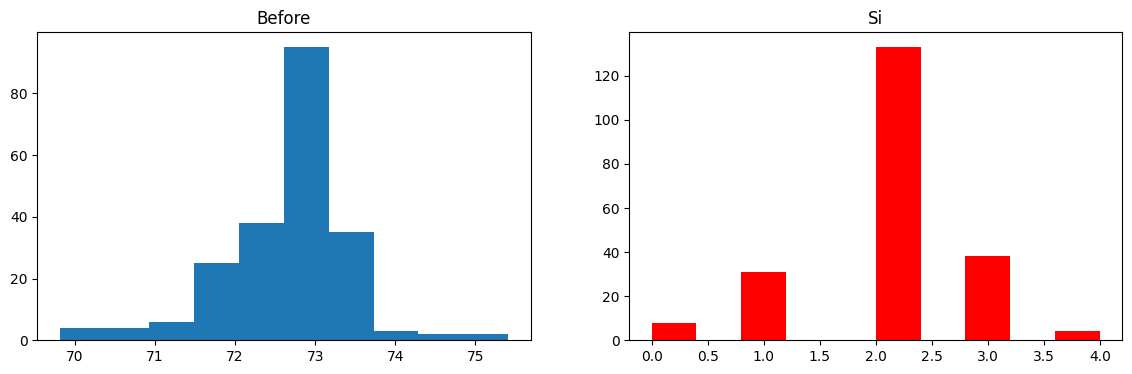

In [133]:
discretize(5,'uniform')